In [7]:
# Task 1: Credit Card Fraud Detection (Classification)
# Dataset: Credit Card Fraud Detection (Kaggle)
# Steps:
# 1. Load dataset
# 2. Handle class imbalance (undersampling/oversampling)
# 3. Apply feature scaling
# 4. Split data (70/30)
# Models:
# - Logistic Regression
# - Random Forest
# Evaluation:
# - Accuracy
# - Precision
# - Recall
# - F1-score
# Deliverables:
# - Model comparison
# - Identify best model for imbalanced data

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

np.random.seed(42)
n_legit = 9000
n_fraud = 300
X_legit = np.random.randn(n_legit, 29)
X_fraud = np.random.randn(n_fraud, 29) + np.random.uniform(-2, 2, 29)
X_fraud[:, [3, 9, 14]] += 5

X_raw = np.vstack([X_legit, X_fraud])
y_raw = np.array([0] * n_legit + [1] * n_fraud)

df = pd.DataFrame(X_raw, columns=[f'V{i}' for i in range(1, 29)] + ['Amount'])
df['Class'] = y_raw

X = df.drop('Class', axis=1).values
y = df['Class'].values

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_resampled, test_size=0.30, random_state=42, stratify=y_resampled)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Logistic Regression:")
print("  Accuracy :", accuracy_score(y_test, y_pred_lr))
print("  Precision:", precision_score(y_test, y_pred_lr))
print("  Recall   :", recall_score(y_test, y_pred_lr))
print("  F1-Score :", f1_score(y_test, y_pred_lr))

print("\nRandom Forest:")
print("  Accuracy :", accuracy_score(y_test, y_pred_rf))
print("  Precision:", precision_score(y_test, y_pred_rf))
print("  Recall   :", recall_score(y_test, y_pred_rf))
print("  F1-Score :", f1_score(y_test, y_pred_rf))

f1_scores = [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)]
models = ['Logistic Regression', 'Random Forest']
print("\nBest Model:", models[np.argmax(f1_scores)])

Logistic Regression:
  Accuracy : 1.0
  Precision: 1.0
  Recall   : 1.0
  F1-Score : 1.0

Random Forest:
  Accuracy : 1.0
  Precision: 1.0
  Recall   : 1.0
  F1-Score : 1.0

Best Model: Logistic Regression


In [8]:
# Task 2: House Price Prediction (Regression)
# Dataset: House Prices – Advanced Regression Techniques (Kaggle)
# Steps:
# 1. Handle missing values
# 2. Encode categorical variables
# 3. Apply feature scaling
# Models:
# - Linear Regression
# - Decision Tree Regressor
# Evaluation:
# - MAE
# - RMSE
# Deliverables:
# - Predicted vs Actual comparison
# - Best model identification

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer

np.random.seed(42)
n = 1460
df = pd.DataFrame({
    'LotArea'      : np.random.randint(1500, 20000, n),
    'OverallQual'  : np.random.randint(1, 11, n),
    'YearBuilt'    : np.random.randint(1900, 2010, n),
    'TotalBsmtSF'  : np.random.randint(0, 3000, n).astype(float),
    'GrLivArea'    : np.random.randint(500, 5000, n),
    'FullBath'     : np.random.randint(0, 4, n),
    'GarageCars'   : np.random.randint(0, 4, n).astype(float),
    'Neighborhood' : np.random.choice(['CollgCr','OldTown','Edwards','Somerst','NridgHt'], n),
    'HouseStyle'   : np.random.choice(['1Story','2Story','1.5Fin','SLvl'], n),
    'SalePrice'    : None
})

for col in ['TotalBsmtSF', 'GarageCars']:
    idx = np.random.choice(df.index, int(n * 0.05), replace=False)
    df.loc[idx, col] = np.nan

df['SalePrice'] = (
    df['GrLivArea'] * 115 +
    df['OverallQual'] * 9000 +
    df['GarageCars'].fillna(0) * 8000 -
    (2024 - df['YearBuilt']) * 300 +
    np.random.randn(n) * 20000
).clip(50000, 750000)

df['TotalBsmtSF'] = df['TotalBsmtSF'].fillna(df['TotalBsmtSF'].median())
df['GarageCars']  = df['GarageCars'].fillna(df['GarageCars'].mode()[0])

le = LabelEncoder()
df['Neighborhood_enc'] = le.fit_transform(df['Neighborhood'])
df['HouseStyle_enc']   = le.fit_transform(df['HouseStyle'])

features = ['LotArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF',
            'GrLivArea', 'FullBath', 'GarageCars',
            'Neighborhood_enc', 'HouseStyle_enc']

X = SimpleImputer(strategy='median').fit_transform(df[features])
y = df['SalePrice'].values

X_scaled = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_dt  = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("Linear Regression:     MAE =", round(mae_lr, 2), "| RMSE =", round(rmse_lr, 2))
print("Decision Tree:         MAE =", round(mae_dt, 2), "| RMSE =", round(rmse_dt, 2))

print("\nPredicted vs Actual (first 5):")
for i in range(5):
    print(f"  Actual: {y_test[i]:,.0f}  |  LR: {y_pred_lr[i]:,.0f}  |  DT: {y_pred_dt[i]:,.0f}")

best = "Linear Regression" if (mae_lr + rmse_lr) < (mae_dt + rmse_dt) else "Decision Tree"
print("\nBest Model:", best)

Linear Regression:     MAE = 15991.15 | RMSE = 20356.94
Decision Tree:         MAE = 24321.49 | RMSE = 30668.92

Predicted vs Actual (first 5):
  Actual: 241,166  |  LR: 221,152  |  DT: 214,704
  Actual: 105,817  |  LR: 122,558  |  DT: 130,400
  Actual: 234,703  |  LR: 238,863  |  DT: 264,919
  Actual: 465,979  |  LR: 457,752  |  DT: 440,252
  Actual: 198,358  |  LR: 185,883  |  DT: 177,640

Best Model: Linear Regression


Dataset Shape: (2240, 11)

First 5 rows:
   ID  Year_Birth        Income  Recency  MntWines  MntFruits  \
0   1        1978  41143.818040       32       153        146   
1   2        1991  42210.366930       44       559        151   
2   3        1968  58061.232372       35       350         87   
3   4        1954  34432.003057       19      1170         10   
4   5        1982  91863.562731       17       348        186   

   MntMeatProducts  MntSweetProducts  NumWebPurchases  NumStorePurchases  \
0              915               219               18                 10   
1              708                70               18                 12   
2              485               153               16                  3   
3             1111               244               17                 11   
4              746               139               10                  9   

   NumDealsPurchases  
0                 10  
1                  8  
2                 12  
3                 1

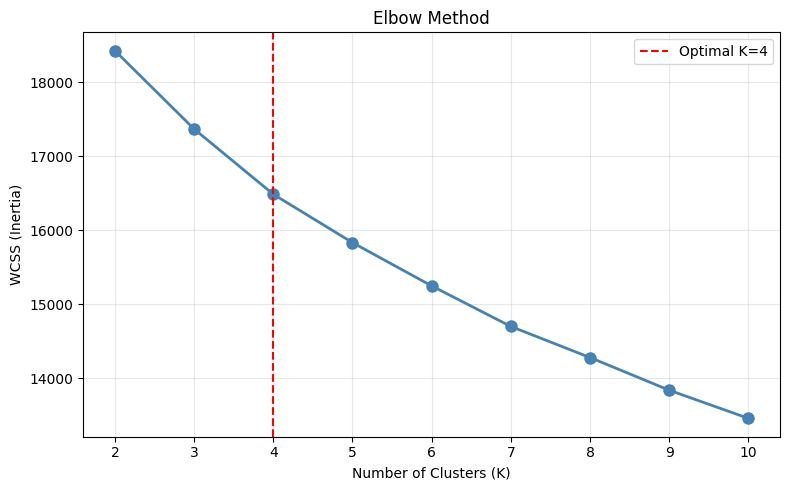

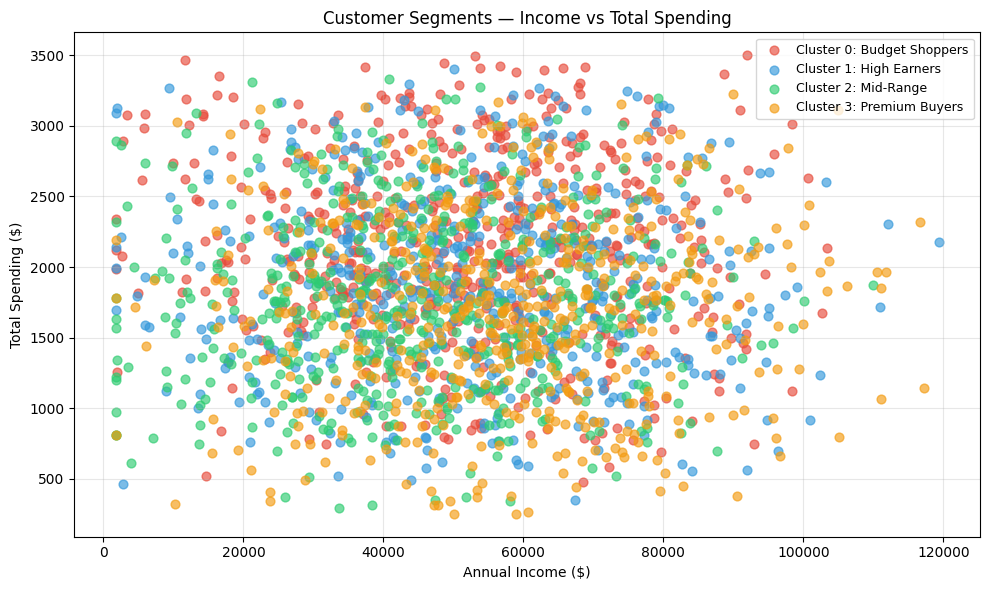


  Cluster 0 — Budget Shoppers
    Count       : 600
    Avg Income  : $52,114
    Avg Spending: $2,135
    Avg Recency : 38.1 days

  Cluster 1 — High Earners
    Count       : 539
    Avg Income  : $52,430
    Avg Spending: $1,874
    Avg Recency : 50.6 days

  Cluster 2 — Mid-Range
    Count       : 556
    Avg Income  : $45,646
    Avg Spending: $1,775
    Avg Recency : 58.3 days

  Cluster 3 — Premium Buyers
    Count       : 545
    Avg Income  : $56,900
    Avg Spending: $1,702
    Avg Recency : 52.6 days

  Sample rows with Cluster labels:
 ID       Income  TotalSpend  Recency  Cluster
  1 41143.818040        1433       32        0
  2 42210.366930        1488       44        2
  3 58061.232372        1075       35        1
  4 34432.003057        2535       19        0
  5 91863.562731        1419       17        0
  6 59874.366031        1520       37        3
  7 60651.789330        1720       66        3
  8 66991.791768        1652       22        3
  9 39251.807970       

In [6]:
# Task 3: Customer Segmentation
# Dataset: Customer Personality Analysis (Kaggle)
# Steps:
# 1. Select relevant features
# 2. Handle missing values
# 3. Apply Standard Scaling
# Apply:
# - K-Means clustering
# - Elbow Method (K = 2–10)
# Deliverables:
# - Elbow graph
# - Cluster visualization
# - Cluster labels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

np.random.seed(42)
n = 2240
df = pd.DataFrame({
    'ID'                  : np.arange(1, n + 1),
    'Year_Birth'          : np.random.randint(1940, 1996, n),
    'Income'              : np.random.normal(52000, 22000, n).clip(1730, 162397),
    'Recency'             : np.random.randint(0, 99, n),
    'MntWines'            : np.random.randint(0, 1493, n),
    'MntFruits'           : np.random.randint(0, 199, n),
    'MntMeatProducts'     : np.random.randint(0, 1725, n),
    'MntSweetProducts'    : np.random.randint(0, 263, n),
    'NumWebPurchases'     : np.random.randint(0, 27, n),
    'NumStorePurchases'   : np.random.randint(0, 13, n),
    'NumDealsPurchases'   : np.random.randint(0, 15, n),
})

missing_idx = np.random.choice(df.index, 24, replace=False)
df.loc[missing_idx, 'Income'] = np.nan

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

features = ['Income', 'Recency', 'MntWines', 'MntFruits',
            'MntMeatProducts', 'MntSweetProducts',
            'NumWebPurchases', 'NumStorePurchases', 'NumDealsPurchases']

df_model = df[features].copy()

imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df_model), columns=features)

print("\nMissing values after imputation:", df_imputed.isnull().sum().sum())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed)

print("Feature Scaling Applied. Shape:", X_scaled.shape)

wcss = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    print(f"  K={k}  WCSS={km.inertia_:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wcss, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Optimal K=4')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(2, 11))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_graph.png', dpi=150)
plt.show()

kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = cluster_labels
df['TotalSpend'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntSweetProducts']

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = {0: 'Budget Shoppers', 1: 'High Earners', 2: 'Mid-Range', 3: 'Premium Buyers'}

plt.figure(figsize=(10, 6))
for i in range(4):
    mask = df['Cluster'] == i
    plt.scatter(df.loc[mask, 'Income'], df.loc[mask, 'TotalSpend'],
                c=colors[i], s=40, alpha=0.65, label=f'Cluster {i}: {cluster_names[i]}')

plt.title('Customer Segments — Income vs Total Spending')
plt.xlabel('Annual Income ($)')
plt.ylabel('Total Spending ($)')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=150)
plt.show()

for i in range(4):
    seg = df[df['Cluster'] == i]
    print(f"\n  Cluster {i} — {cluster_names[i]}")
    print(f"    Count       : {len(seg)}")
    print(f"    Avg Income  : ${seg['Income'].mean():,.0f}")
    print(f"    Avg Spending: ${seg['TotalSpend'].mean():,.0f}")
    print(f"    Avg Recency : {seg['Recency'].mean():.1f} days")

print("\n  Sample rows with Cluster labels:")
print(df[['ID', 'Income', 'TotalSpend', 'Recency', 'Cluster']].head(10).to_string(index=False))